<a href="https://colab.research.google.com/github/sathwikdbhat/Java-Training/blob/master/Gen_AI_Lab_(New_Version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Explore pre-trained word vectors. Explore word relationships using vector arithmetic. Perform arithmetic operations and analyze results.

In [ ]:
#!pip install gensim
import gensim.downloader as api

model = api.load("word2vec-google-news-300")
print("\nSimilar to 'king':")
for w, s in model.most_similar("king", topn=5):
    print(w, round(s,4))
res = model.most_similar(positive=['king','woman'], negative=['man'], topn=1)
print("\nking - man + woman =", res[0][0])

sim = model.similarity("king","queen")
print("\nSimilarity between king and queen:", round(sim,4))
words = ["apple","banana","grape","car"]
print("\nOdd one out:", model.doesnt_match(words))


Similar to 'king':
kings 0.7138
queen 0.6511
monarch 0.6413
crown_prince 0.6204
prince 0.616

king - man + woman = queen

Similarity between king and queen: 0.6511

Odd one out: car


2. Use dimensionality reduction (e.g., PCA or t-SNE) to visualize word embeddings for Q 1. Select 10 words from a specific domain (e.g., sports, technology) and visualize their embeddings. Analyze clusters and relationships. Generate contextually rich outputs using embeddings. Write a program to generate 5 semantically similar words for a given input.

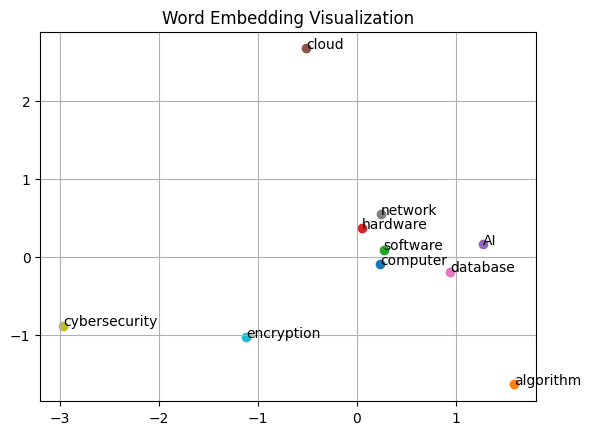


Similar to 'AI':
Steven_Spielberg_Artificial_Intelligence 0.5576
Index_MDE_##/###/#### 0.5415
Enemy_AI 0.5256
Ace_Combat_Zero 0.5227
DOA4 0.5183


In [ ]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model = api.load("word2vec-google-news-300")
words = ["computer","algorithm","software","hardware","AI","cloud","database","network","cybersecurity","encryption"]
vectors = [model[w] for w in words]
pca = PCA(n_components=2).fit_transform(vectors)
for i,w in enumerate(words):
    x,y = pca[i]
    plt.scatter(x,y)
    plt.text(x,y,w)

plt.title("Word Embedding Visualization")
plt.grid()
plt.show()
print("\nSimilar to 'AI':")
for w,s in model.most_similar("AI",topn=5):
    print(w,round(s,4))

3. Train a custom Word2Vec model on a small dataset. Train embeddings on a
domain-specific corpus (e.g., legal, medical) and analyze how embeddings capture domain-specific semantics.

Similar to diabetes:
treats 0.27
diseases 0.211
to 0.167
patient 0.161
unhygiene 0.15


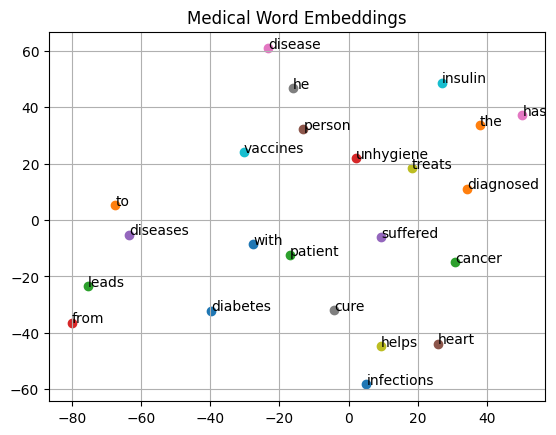

In [ ]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

corpus = ["The patient diagnosed with diabetes", "Insulin treats diabetes", "He has heart diseases", "Unhygiene leads to infections", "Vaccines helps cure disease", "The person suffered from cancer"]
data = [s.lower().split() for s in corpus]
model = Word2Vec(data, vector_size=50, window=5, min_count=1)
print("Similar to diabetes:")
for w,s in model.wv.most_similar("diabetes",topn=5):
    print(w,round(s,3))

words = list(model.wv.index_to_key)
vectors = model.wv[words]
tsne = TSNE(n_components=2, perplexity=5, random_state=0).fit_transform(vectors)
for i,w in enumerate(words):
    x,y = tsne[i]
    plt.scatter(x,y)
    plt.text(x,y,w)
plt.title("Medical Word Embeddings")
plt.grid()
plt.show()

4. Use word embeddings to improve prompts for Generative AI model. Retrieve similar words using word embeddings. Use the similar words to enrich a
GenAI prompt. Use the AI model to generate responses for the original and
enriched prompts. Compare the outputs in terms of detail and relevance.

In [ ]:
import gensim.downloader as api
from transformers import pipeline

model = api.load("glove-twitter-25")
original = "The forest is beautiful"
synonyms = [w for w,s in model.most_similar("beautiful",topn=3)]
enriched = original + " " + " ".join(synonyms)
gen = pipeline("text-generation", model="gpt2")

out1 = gen(original, max_new_tokens=30)[0]['generated_text']
out2 = gen(enriched, max_new_tokens=30)[0]['generated_text']
print("\nOriginal Output:")
print(out1)
print("\nEnriched Output:")
print(out2)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Original Output:
The forest is beautiful with a huge canopy of black trees and trees of green.

We have a lot of people who have already come here. We have a lot

Enriched Output:
The forest is beautiful gorgeous lovely amazing beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful beautiful


5. Use word embeddings to create meaningful sentences for creative tasks.
Retrieve similar words for a seed word. Create a sentence or story using these
words as a starting point. Write a program that: Takes a seed word. Generates
similar words. Constructs a short paragraph using these words

In [ ]:
import gensim.downloader as api
import random

model = api.load("glove-wiki-gigaword-50")
seed = input("Enter seed word: ").lower()
words = [w for w,s in model.most_similar(seed,topn=5)]

story = f""" The story of the {seed} began in a distant land. It met a {random.choice(words)} near a mysterious {random.choice(words)}. The {seed} discovered {random.choice(words)} and continued the adventure with {random.choice(words)} leading to {random.choice(words)}. """
print("\nGenerated Story:\n")
print(story)

Enter seed word: man

Generated Story:

 The story of the man began in a distant land. It met a one near a mysterious old. The man discovered old and continued the adventure with one leading to boy. 


6. Use a pre-trained Hugging Face model to analyze sentiment in text. Assume a
real-world application, Load the sentiment analysis pipeline. Analyze the
sentiment by giving sentences to input.

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
while True:
    text = input("Enter sentence (or exit): ")
    if text.lower() == "exit":
        break
    res = classifier(text)[0]
    print("Sentiment:", res['label'], "Score:", round(res['score'],3))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Enter sentence (or exit): The product is very expensive and not a good quality
Sentiment: NEGATIVE Score: 1.0
Enter sentence (or exit): It is very affordable and a nice one
Sentiment: POSITIVE Score: 1.0
Enter sentence (or exit): exit


7. Summarize long texts using a pre-trained summarization model using Hugging
face model. Load the summarization pipeline. Take a passage as input and
obtain the summarized text.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
text = input("Enter text:\n")

inputs = tokenizer(text, return_tensors="pt", truncation=True)
ids = model.generate(inputs["input_ids"], max_length=60, min_length=20)
print("\nSummary:")
print(tokenizer.decode(ids[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Enter text:
Initial jobless claims in the US fell to 207K last week, below forecasts of 215K, the biggest drop since February, signaling layoffs remain limited as the labor market and economy stay resilient. Meanwhile, continuing claims rose to 1,818K in the week ended April 4th, up 31K from the previous week.

Summary:
 Initial jobless claims in the US fell to 207K last week, below forecasts of 215K, the biggest drop since February . Continuing claims rose to 1,818K in the week ended April 4th, up 31K from the previous week .


8. Install langchain, cohere (for key), langchain-community. Get the api key( By
logging into Cohere and obtaining the cohere key). Load a text document from your google drive . Create a prompt template to display the output in a particular manner

In [ ]:
#!pip install langchain-community cohere langchain-cohere
'''from langchain_core.prompts import PromptTemplate
from langchain_cohere import Cohere

key = "YOUR_COHERE_API"
with open("AI.txt","r") as f:
    text = f.read()
prompt = PromptTemplate(
    input_variables=["t"],
    template="Summarize the text:\n{t}"
)

llm = Cohere(cohere_api_key=key)
result = llm.invoke(prompt.format(t=text))
print(result)'''

'''============================================================================='''

from langchain_core.prompts import PromptTemplate
from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline

pipe = pipeline("text-generation", model="gpt2", max_new_tokens=40)
llm = HuggingFacePipeline(pipeline=pipe)
with open("AI.txt","r") as f:
    text = f.read()

prompt = PromptTemplate(
    input_variables=["t"],
    template="Summarize this text:\n{t}"
)
chain = prompt | llm
print(chain.invoke({"t": text}))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Summarize this text:
Act as a Senior Full-Stack Java Engineer and Technical Lead. I am a beginner developer on a Windows 11 system with absolutely no coding experience. We are going to build a Proof of Concept (POC) called "LogiPulse: An Autonomous AI Control Tower for Resilient Domestic Supply Chains" over a strict 7-day sprint. I will be using an AI, a smart contract, and a decentralized, scalable network of dedicated hardware, software, and business capabilities to build and execute a completely decentralized cloud, a self-sust


9. Take the Institution name as input. Use Pydantic to define the schema for the
desired output and create a custom output parser. Invoke the Chain and Fetch
Results. Extract the below Institution related details from Wikipedia: The
founder of the Institution. When it was founded. The current branches in the
institution . How many employees are working in it. A brief 4-line summary of
the institution.

In [ ]:
#!pip install wikipedia
from pydantic import BaseModel
import wikipedia

class Institution(BaseModel):
    name:str
    founder:str
    founded:str
    branches:str
    employees:str
    summary:str
name = input("Enter Institution Name: ")
page = wikipedia.page(name)
summary = ". ".join(page.summary.split(".")[:4]) + "."

data = Institution(
    name = page.title,
    founder = "Check Wikipedia",
    founded = "Check Wikipedia",
    branches = "Multiple",
    employees = "N/A",
    summary = summary
)
print(data.model_dump_json(indent=4))

Enter Institution Name: Harverd University
{
    "name": "Harvard University",
    "founder": "Check Wikipedia",
    "founded": "Check Wikipedia",
    "branches": "Multiple",
    "employees": "N/A",
    "summary": "Harvard University is a private Ivy League research university in Cambridge, Massachusetts, United States.  Founded in 1636, and named Harvard College in 1639 in honor of its first benefactor, Puritan clergyman John Harvard, it is the oldest institution of higher learning in the United States.  Its influence, wealth, and rankings have made it one of the most prestigious universities in the world. \nHarvard was founded and authorized by the Massachusetts General Court, the governing legislature of colonial-era Massachusetts Bay Colony."
}


10. Build a chatbot for the Indian Penal Code. We'll start by downloading the
official Indian Penal Code document, and then we'll create a chatbot that can
interact with it. Users will be able to ask questions about the Indian Penal
Code and have a conversation with it.

In [ ]:
#!pip install PyPDF2
import PyPDF2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def get_pdf_text(file):
    text=""
    with open(file,"rb") as f:
        pdf=PyPDF2.PdfReader(f)
        for p in pdf.pages[:30]:
            text+=p.extract_text()
    return text
print("Loading IPC...")
text=get_pdf_text("ipc.pdf")
sections=[s.strip() for s in text.split("Section") if len(s)>20]

while True:
    q=input("\nAsk IPC (or exit): ")
    if q.lower()=="exit":
        break
    vec=TfidfVectorizer()
    mat=vec.fit_transform(sections+[q])
    sim=cosine_similarity(mat[-1],mat[:-1]).flatten()
    print("\nResult:",sections[sim.argmax()][:400],"...")

Loading IPC...

Ask IPC (or exit): Punishment

Result: ”. 
51. “Oath ”. 
52. “Good faith”. 
52A. “Harbour-“. 
 
CHAPTER III 
OF PUNISHMENTS 
53. Punishments. 
53A. Construction of reference to transportation. 
54. Commutation of sentence of death. 
55. Commutation of sentence of imprisonment for life. 
55A. Definition of "appropriate Government". 
56. [Repealed .]. 
57. Fractions of terms of punishment. 
58. [Repealed. ]. 
59. [Repealed .]. 
60. Sente ...

Ask IPC (or exit): Arrest

Result: ”.—The word “section ” denotes one of those portions of a Chapter of this Code which 
are distinguished by prefixed numeral figures. 
51. “Oath ”.—The word “oath” includes a solemn affirmation substituted by law for an oath, and any 
declaration required or authorised by law to be made before a public servant or t o be used for the purpose 
of proof, whether in a Court of Justice or not. 
52. “Goo ...

Ask IPC (or exit): exit
